In [1]:
from keras.utils import image_dataset_from_directory
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
import tensorflow as tf
from tensorflow.keras.models import Model,load_model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Rescaling,Resizing
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from sklearn.metrics import classification_report,confusion_matrix
from collections import Counter
import random
import shap

import numpy as np
import matplotlib.pyplot as plt
import prettypyplot as pplt
import seaborn as sns

import cv2
import os
import shutil
from PIL import Image

c:\Users\ahmed\anaconda3\envs\blood_cells_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
train_ds=image_dataset_from_directory('../train_oversampling',seed=42,batch_size=16,image_size=(363,360))
class_names=train_ds.class_names
val_ds=image_dataset_from_directory('../val',seed=42,batch_size=16,image_size=(363,360),label_mode='int')
test_ds=image_dataset_from_directory('../test',seed=42,batch_size=16,image_size=(363,360),label_mode='int')

Found 18640 files belonging to 8 classes.
Found 2564 files belonging to 8 classes.
Found 2569 files belonging to 8 classes.


In [20]:
#preprocessing the oversampled data
train_ds=train_ds.map(lambda x,y:(preprocess_input(x),y))
val_ds=val_ds.map(lambda x,y:(preprocess_input(x),y))
test_ds=test_ds.map(lambda x,y:(preprocess_input(x),y))

In [ ]:
base_model=InceptionV3(weights='imagenet',include_top=False)
base_model.trainable=True
inputs=Input(shape=(363,360,3))
x=Resizing(224,224)(inputs)
x=Rescaling(1/255)(x)

x=base_model(x)
x=GlobalAveragePooling2D()(x)
x=Dense(1024,activation='relu')(x)
x=Dropout(rate=0.2)(x)
x=Dense(512,activation='relu')(x)
x=Dropout(rate=0.2)(x)
outputs=Dense(8,activation='softmax')(x)
model=Model(inputs=inputs,outputs=outputs)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
for i, layer in enumerate(base_model.layers):
    print(f"{i+1:3}: {layer.name:40} — Trainable: {layer.trainable}")

  1: input_layer_2                            — Trainable: True
  2: conv2d_188                               — Trainable: True
  3: batch_normalization_188                  — Trainable: True
  4: activation_188                           — Trainable: True
  5: conv2d_189                               — Trainable: True
  6: batch_normalization_189                  — Trainable: True
  7: activation_189                           — Trainable: True
  8: conv2d_190                               — Trainable: True
  9: batch_normalization_190                  — Trainable: True
 10: activation_190                           — Trainable: True
 11: max_pooling2d_8                          — Trainable: True
 12: conv2d_191                               — Trainable: True
 13: batch_normalization_191                  — Trainable: True
 14: activation_191                           — Trainable: True
 15: conv2d_192                               — Trainable: True
 16: batch_normalization_192            

In [11]:
early_stopping = EarlyStopping(
    monitor='val_loss',     # or 'val_accuracy'
    patience=5,             # wait 5 epochs before stopping
    mode='min',min_delta=0.01,
    restore_best_weights=True  # keep the best weights
)
reduceLR=ReduceLROnPlateau(monitor='val_loss',factor=0.1,min_lr=1e-6,patience=3,
                           min_delta=0.01,cooldown=4)

In [12]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [13]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 363, 360, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,429,864 (93.19 MB)

 Trainable params: 24,395,432 (93.06 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [14]:
history_model=model.fit(train_ds,validation_data=val_ds,epochs=100,callbacks=[early_stopping,reduceLR])

Epoch 1/100


I0000 00:00:1753709658.935547     108 service.cc:148] XLA service 0x7d5e74002f20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1753709658.936985     108 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1753709658.937009     108 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1753709664.511396     108 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1753709695.081513     108 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1165/1165 ━━━━━━━━━━━━━━━━━━━━ 268s 154ms/step - accuracy: 0.7783 - loss: 0.6982 - val_accuracy: 0.6404 - val_loss: 1.4673 - learning_rate: 0.0010
Epoch 2/100
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 172s 147ms/step - accuracy: 0.9305 - loss: 0.2335 - val_accuracy: 0.7843 - val_loss: 0.7502 - learning_rate: 0.0010
Epoch 3/100
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 172s 147ms/step - accuracy: 0.9530 - loss: 0.1637 - val_accuracy: 0.8261 - val_loss: 0.7146 - learning_rate: 0.0010
Epoch 4/100
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 171s 147ms/step - accuracy: 0.9611 - loss: 0.1384 - val_accuracy: 0.3576 - val_loss: 2.4847 - learning_rate: 0.0010
Epoch 5/100
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 171s 147ms/step - accuracy: 0.9636 - loss: 0.1249 - val_accuracy: 0.3721 - val_loss: 5.2476 - learning_rate: 0.0010
Epoch 6/100
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 171s 146ms/step - accuracy: 0.9662 - loss: 0.1114 - val_accuracy: 0.4828 - val_loss: 3.1631 - learning_rate: 0.0010
Epoch 7/100
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 172s 147ms/step

In [4]:
model=load_model('inceptionv3_224_224.h5')
history=np.loadtxt('inceptionv3_model_history.txt')

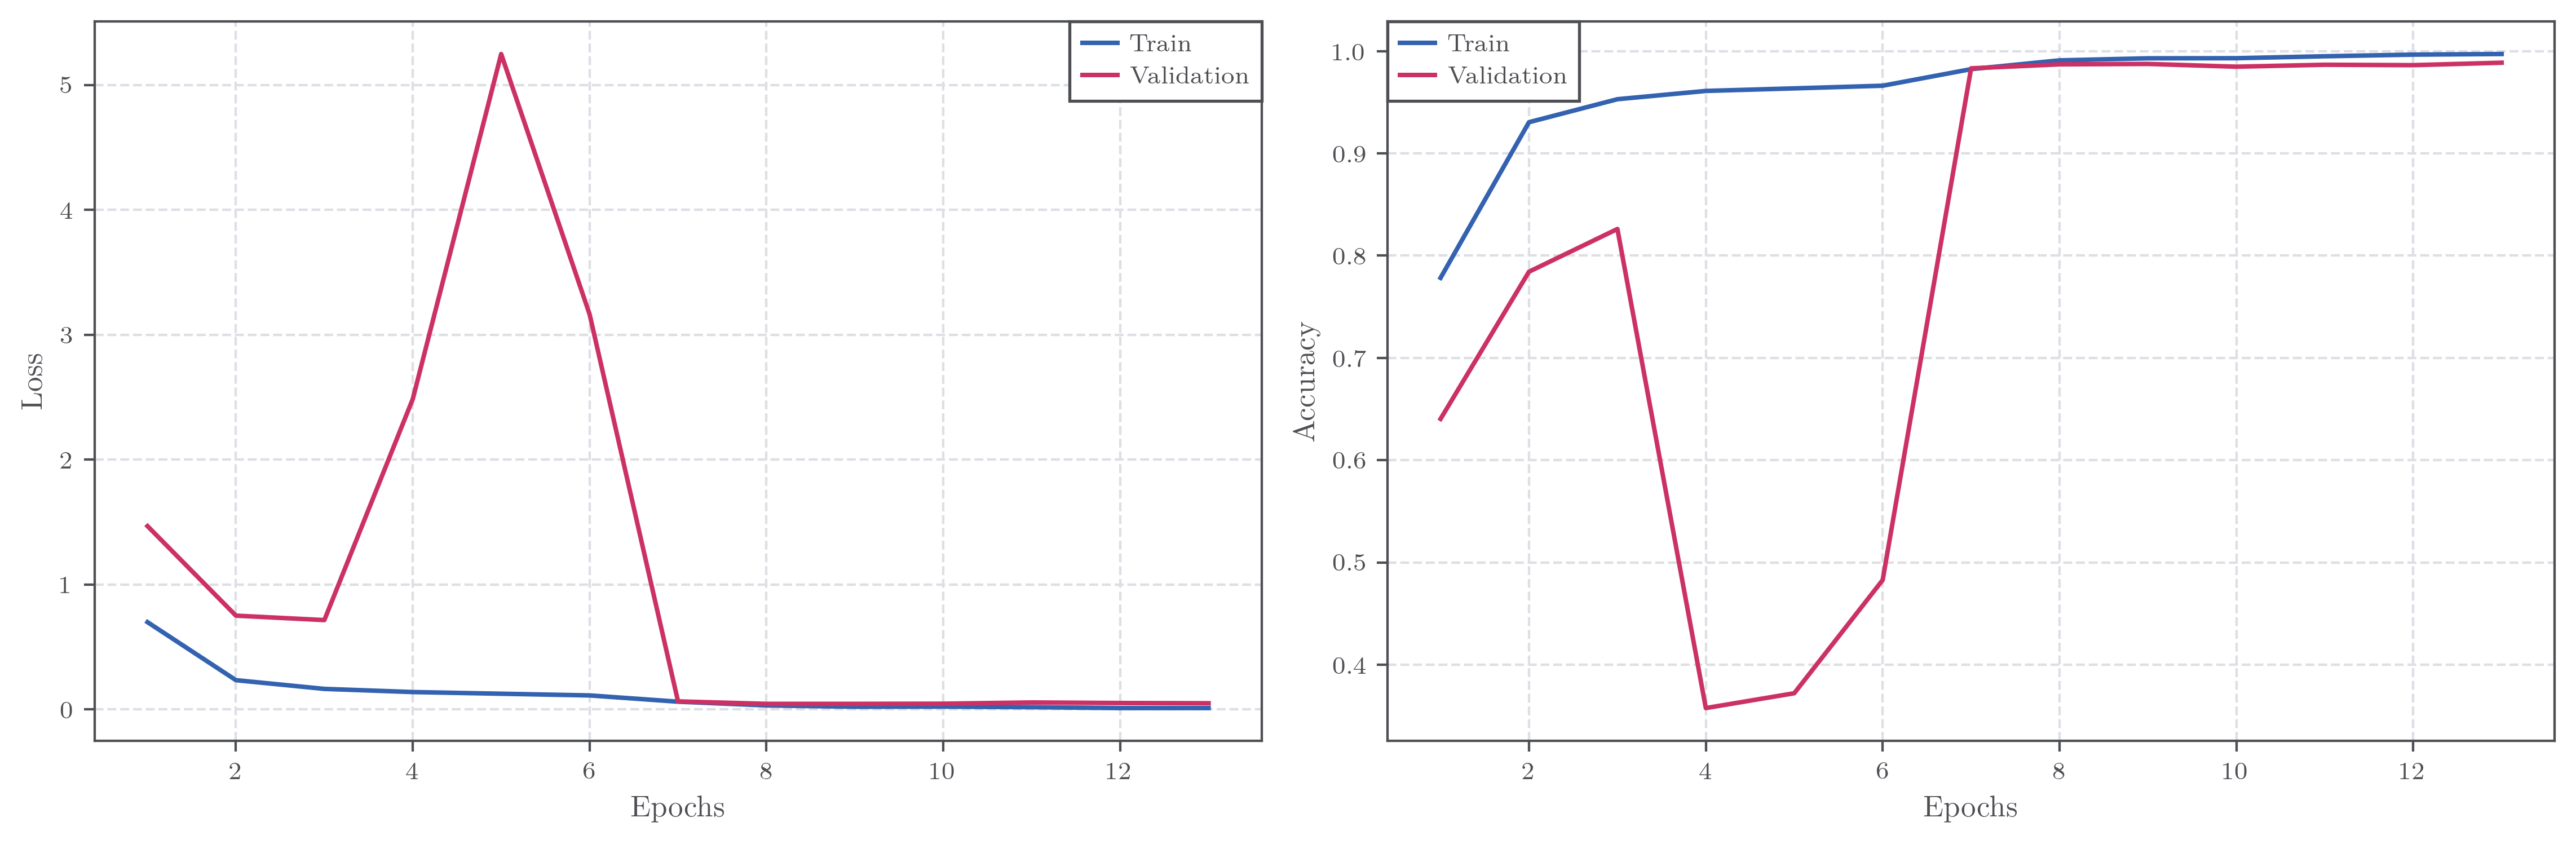

In [6]:
pplt.use_style()
loss=history[:,2]
val_loss=history[:,4]
accuracy=history[:,1]
val_accuracy=history[:,3]
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.plot(np.arange(len(loss))+1,loss,label='Train')
plt.plot(np.arange(len(val_loss))+1,val_loss,label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend();
plt.subplot(122)
plt.plot(np.arange(len(accuracy))+1,accuracy,label='Train')
plt.plot(np.arange(len(val_accuracy))+1,val_accuracy,label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
pplt.savefig('loss_acc_inceptionv3.pdf');

In [7]:
def get_predictions_and_labels(dataset):
    true_labels = []
    pred_labels = []

    for images, labels in dataset:

        preds = model.predict(images, verbose=0)  # Get the model's predictions
        pred_labels.extend(np.argmax(preds, axis=-1))  # Get the predicted labels (argmax)

        true_labels.extend(labels.numpy())  # Get the true labels

    return np.array(true_labels), np.array(pred_labels)

y_true, y_pred = get_predictions_and_labels(test_ds)

In [ ]:
report=classification_report(y_true, y_pred, target_names=class_names)


In [8]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    basophil       0.99      0.99      0.99       183
  eosinophil       1.00      1.00      1.00       468
erythroblast       1.00      0.97      0.98       233
          ig       0.97      0.95      0.96       435
  lymphocyte       0.98      1.00      0.99       183
    monocyte       0.96      0.98      0.97       214
  neutrophil       0.97      0.98      0.98       500
    platelet       1.00      1.00      1.00       353

    accuracy                           0.98      2569
   macro avg       0.98      0.98      0.98      2569
weighted avg       0.98      0.98      0.98      2569



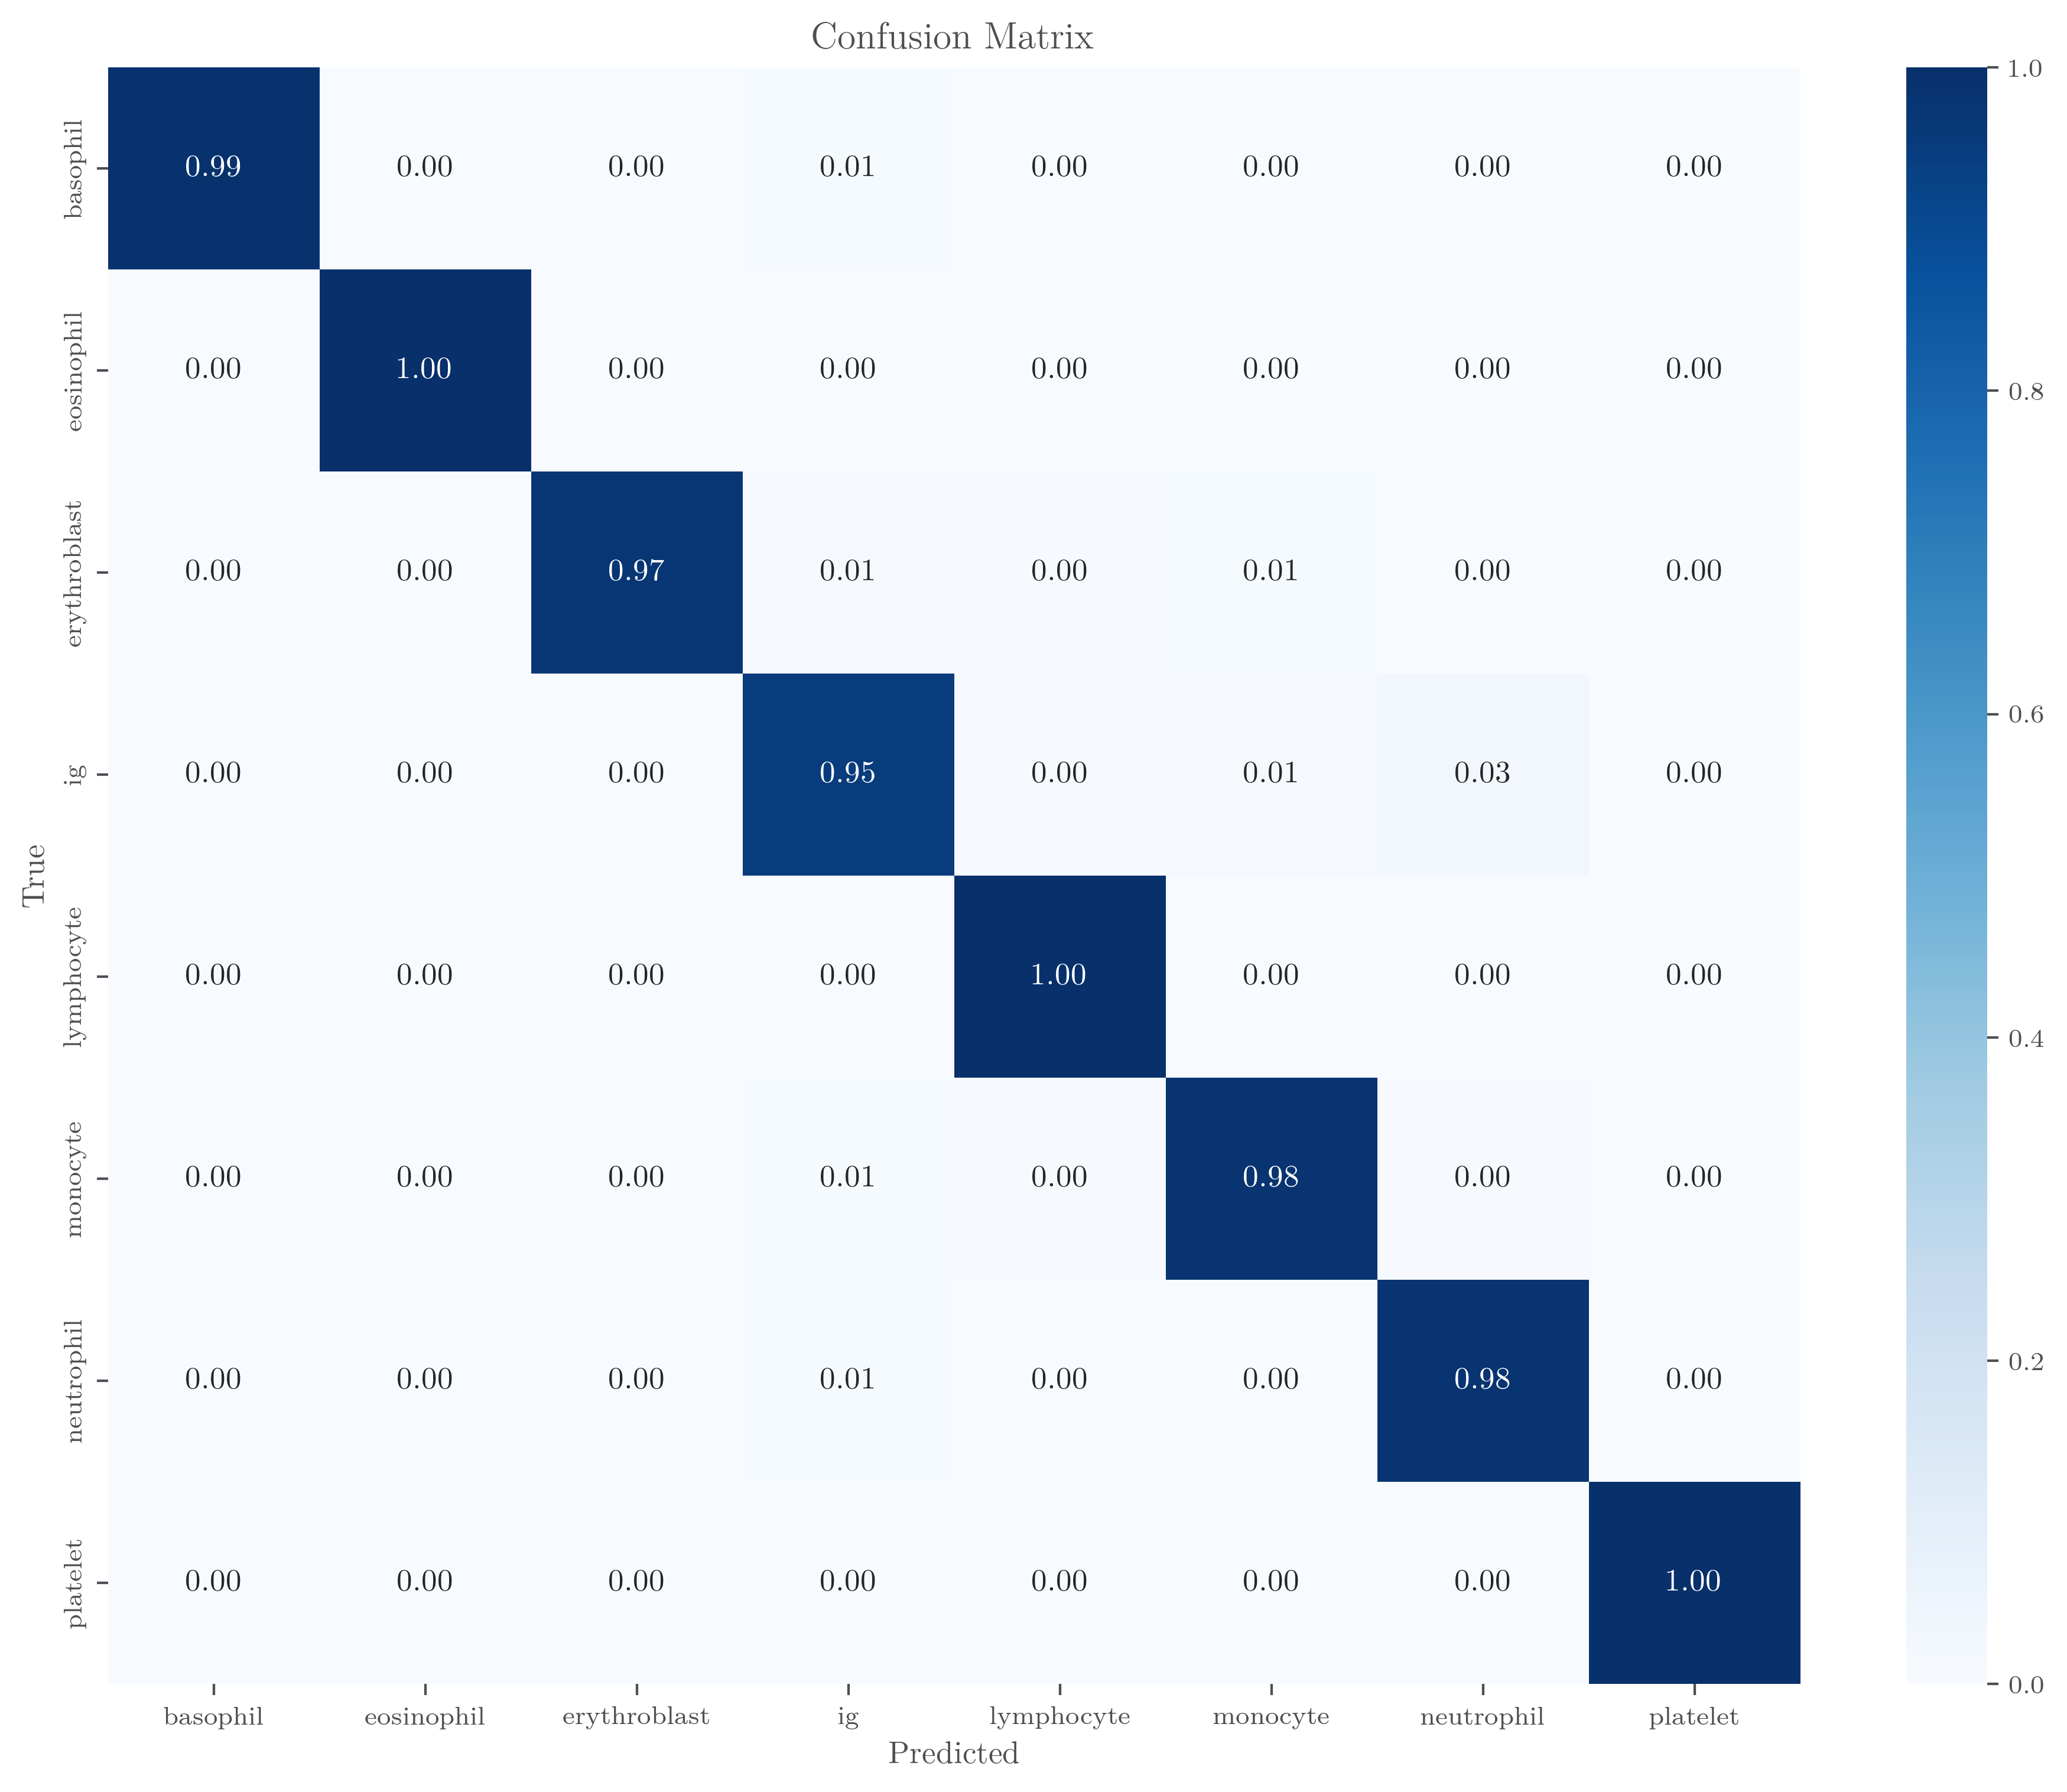

In [15]:
cm = confusion_matrix(y_true, y_pred,normalize='true')
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, xticklabels=class_names, yticklabels=class_names, fmt='.2f', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
pplt.savefig('cm_inceptionv3.pdf')
plt.show()

In [ ]:
#model.save("inceptionv3_224_224.h5")

In [16]:
def preprocess_image(image):
    image_resized = tf.image.resize(image, (224, 224))
    image_preprocessed = preprocess_input(image_resized)
    return image_preprocessed
test_ds=test_ds.map(lambda x,y:(preprocess_image(x),y))

In [39]:
X = np.array([img.numpy() for img, _ in test_ds.take(2)][0]).astype(np.uint8)
y = np.array([label.numpy() for _, label in test_ds.take(2)][0])

# Select specific images
images = X[:2]
labels = y[:2]

In [45]:
def grad_cam(image,model,layer_name):
    layer=model.layers[3].get_layer(layer_name)
    print (layer)
    grad_model=Model(inputs=model.input,outputs=[layer.output,model.output])
    image=tf.expand_dims(image,axis=0)
    with tf.GradientTape() as tape:
        conv_outputs,predictions=grad_model(image)
        predicted_class=tf.argmax(predictions[0])
        loss=predictions[:,predicted_class]
    grads=tape.gradient(loss,conv_outputs)
    pooled_grads=tf.reduce_mean(grads,axis=(0,1,2))
    conv_outputs = conv_outputs[0]  # Remove the batch dimension
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = tf.maximum(heatmap, 0)  # Focus only on positive values
    heatmap /= tf.math.reduce_max(heatmap)  # Normalize between 0 and 1
    heatmap = heatmap.numpy()
    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], (image.shape[1], image.shape[2])).numpy()
    heatmap_resized = np.squeeze(heatmap_resized, axis=-1)
    heatmap_colored = plt.cm.jet(heatmap_resized)[..., :3]
    superimposed_image = heatmap_colored * 0.7 + image[0].numpy() / 255.0

    return np.clip(superimposed_image, 0, 1), predicted_class

conv2d_279
<Conv2D name=conv2d_279, built=True>


KeyError: "Exception encountered when calling Functional.call().\n\n\x1b[1m2005385249136\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=tf.Tensor(shape=(1, 363, 360, 3), dtype=uint8)\n  • training=None\n  • mask=None\n  • kwargs=<class 'inspect._empty'>"

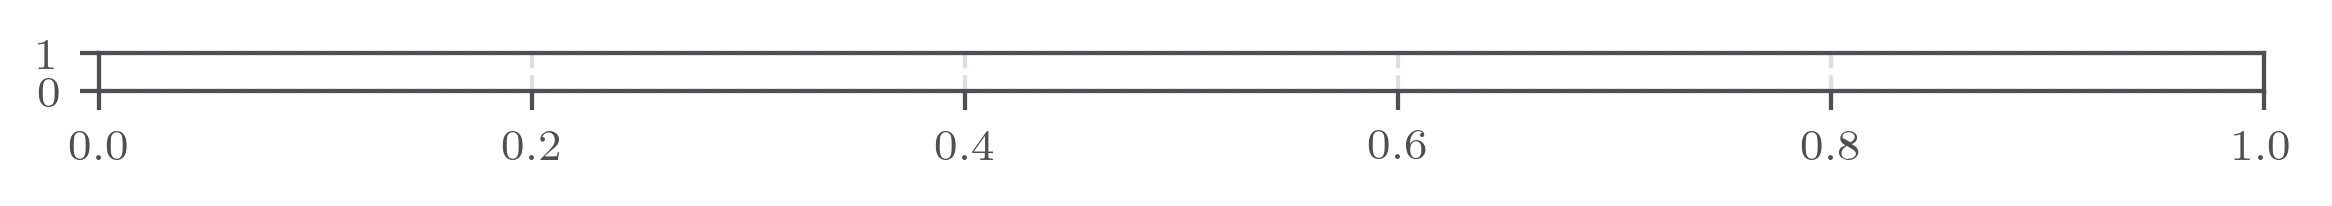

In [46]:
number_of_images = images.shape[0]
conv_layers = [layer.name for layer in model.layers[3].layers if isinstance(layer, Conv2D)]
plt.figure(figsize=(16,16))

for j, layer in enumerate(conv_layers[-4:]):
    print (layer)
    for i in range(number_of_images):

        subplot_index = i + 1 + j * number_of_images
        plt.subplot(len(conv_layers), number_of_images, subplot_index)

            # Get the image with the overlaid heatmap
        grad_cam_image, predicted_class = grad_cam(images[i], model, layer)
            
            # Display the image with Grad-CAM
        plt.title(f'Grad-CAM {layer}')
        plt.imshow(grad_cam_image)
        plt.axis("off")

plt.show()

PartitionExplainer explainer: 3it [05:55, 177.92s/it]              


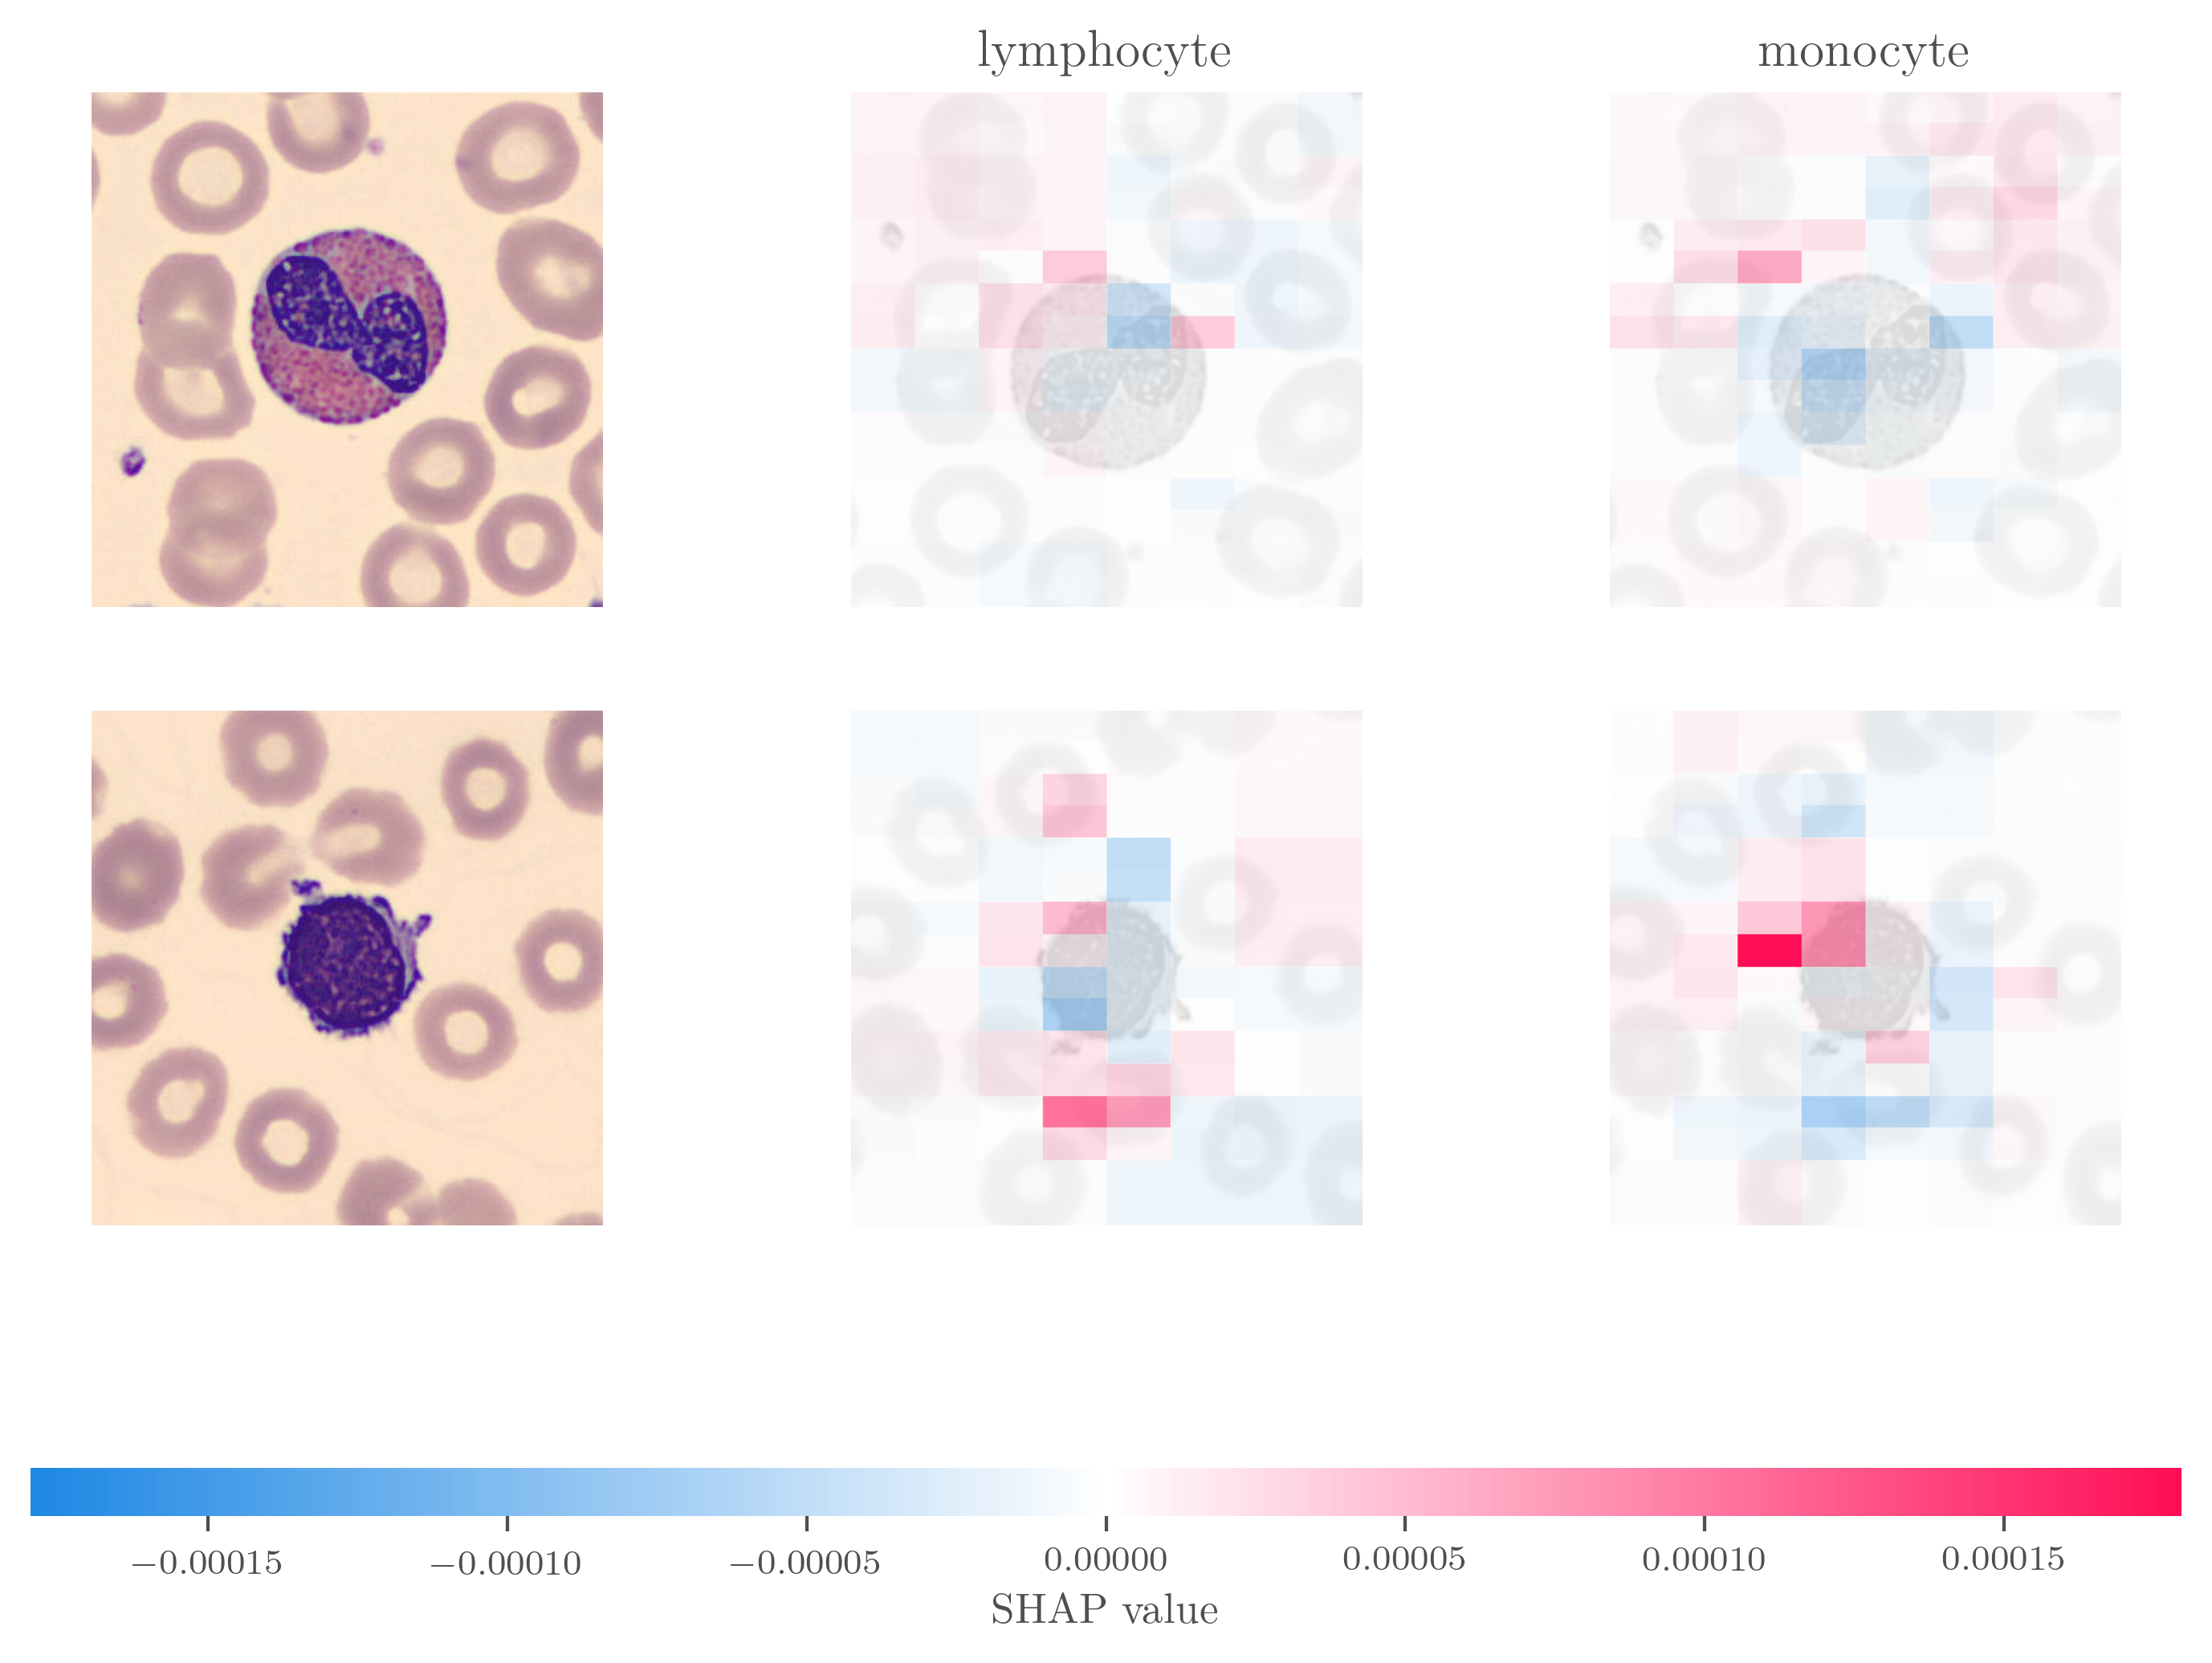

In [44]:
masker=shap.maskers.Image('inpaint_telea',images[0].shape)
explainer=shap.Explainer(model,masker,output_names=class_names)
shap_values=explainer(images,max_evals=1000,outputs=shap.Explanation.argsort.flip[:2])
shap.image_plot(shap_values,show=False)
plt.savefig('shap.pdf');